In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import re

### AMIE

#### Úloha 1 - Asociační pravidla mezi mutacemi genů

In [112]:

# Načtení AMIE výsledků
amie_lines = []
with open('amie_results_v2.tsv', 'r') as f:
    for line in f:
        if line.startswith('?') and '=>' in line:
            amie_lines.append(line.strip())

print(f"Celkem pravidel z AMIE: {len(amie_lines)}")

# Parsování pravidel
rules = []
for line in amie_lines:
    parts = line.split('\t')
    rule_text = parts[0].strip()
    body, head = rule_text.split(' => ')
    rules.append({
        'rule': rule_text,
        'head': head.strip(),
        'body': body.strip(),
        'head_coverage': float(parts[1].replace(',', '.')),
        'std_confidence': float(parts[2].replace(',', '.')),
        'pca_confidence': float(parts[3].replace(',', '.')),
        'positive_examples': int(parts[4]),
    })

df_amie = pd.DataFrame(rules)
print(f"Pravidel celkem: {len(df_amie)}")
print(f"\nPredikáty v hlavě pravidel:")
print(df_amie['head'].str.extract(r'\?\w+\s+(\w+)\s+')[0].value_counts())

Celkem pravidel z AMIE: 189586
Pravidel celkem: 189586

Predikáty v hlavě pravidel:
0
maPohlavi               108809
maSuperPopulaci          80681
maDopad                     44
maMAFKategorii              37
maDominantniPopulaci        14
maVariantu                   1
Name: count, dtype: int64


In [113]:
# === ÚLOHA 1: Pravidla mutace ↔ mutace ===

# Post-filtrace: PCA confidence >= 0.8 (srovnatelné s FP-Growth confidence >= 0.8)
PCA_THRESHOLD = 0.8

# Filtrujeme pravidla kde hlava obsahuje maVariantu (predikce jedné varianty z jiných)
df_u1 = df_amie[
    (df_amie['head'].str.contains('maVariantu')) &
    (df_amie['pca_confidence'] >= PCA_THRESHOLD)
].copy()

# Odfiltrujeme pravidla obsahující konkrétní osoby (HG/NA ID)
df_u1_no_person = df_u1[~df_u1['rule'].str.contains(r'\b(?:HG|NA)\d{4,5}\b', regex=True)].copy()

print(f"Pravidel s maVariantu v hlavě (PCA >= {PCA_THRESHOLD}): {len(df_u1)}")
print(f"Pravidel bez konkrétních osob: {len(df_u1_no_person)}")

# Zobrazíme všechna pravidla
if len(df_u1) > 0:
    print(f"\n=== Pravidla maVariantu (PCA >= {PCA_THRESHOLD}) ===")
    for _, row in df_u1.sort_values('pca_confidence', ascending=False).iterrows():
        print(f"  {row['rule']}")
        print(f"    HC={row['head_coverage']:.3f}  Conf={row['std_confidence']:.3f}  PCA={row['pca_confidence']:.3f}  Příklady={row['positive_examples']}")
        print()
else:
    print(f"\nŽádná přímá pravidla maVariantu nesplňují PCA >= {PCA_THRESHOLD}.")
    print("To je očekávané — AMIE při 8 550 variantách a min HC >= 0.05 generuje")
    print("přímá pravidla jen pro nejfrekventovanější varianty s nižší confidence.")

Pravidel s maVariantu v hlavě (PCA >= 0.8): 0
Pravidel bez konkrétních osob: 0

Žádná přímá pravidla maVariantu nesplňují PCA >= 0.8.
To je očekávané — AMIE při 8 550 variantách a min HC >= 0.05 generuje
přímá pravidla jen pro nejfrekventovanější varianty s nižší confidence.


In [114]:
# Rozšířený pohled: pravidla kde tělo obsahuje více atomů s maVariantu
# (ko-výskyt mutací, i když hlava predikuje něco jiného — typicky maSuperPopulaci)
# Tato pravidla implicitně zachycují LD: "kdo má mutaci X A mutaci Y => patří do populace Z"

df_multi_var = df_amie[
    (df_amie['body'].str.count('maVariantu') >= 2) &
    (df_amie['pca_confidence'] >= PCA_THRESHOLD)
].copy()
print(f"Pravidel s ≥2 atomy maVariantu v těle (PCA >= {PCA_THRESHOLD}): {len(df_multi_var)}")

# Odfiltrujeme konkrétní osoby
df_multi_var_clean = df_multi_var[
    ~df_multi_var['rule'].str.contains(r'\b(?:HG|NA)\d{4,5}\b', regex=True)
].copy()
print(f"Bez konkrétních osob: {len(df_multi_var_clean)}")

# Predikáty v hlavě těchto pravidel
print(f"\nPredikáty v hlavě pravidel s ≥2 variantami v těle:")
print(df_multi_var_clean['head'].str.extract(r'\?\w+\s+(\w+)\s+')[0].value_counts())

Pravidel s ≥2 atomy maVariantu v těle (PCA >= 0.8): 36619
Bez konkrétních osob: 36619

Predikáty v hlavě pravidel s ≥2 variantami v těle:
0
maSuperPopulaci    36619
Name: count, dtype: int64


In [115]:
# Extrakce páru mutací z pravidel s 2 variantami v těle
# Tyto páry představují ko-výskyt (LD) — obě mutace se vyskytují u stejné osoby

def extract_variant_pairs(body_text):
    """Extrahuje varianty z těla pravidla."""
    variants = re.findall(r'maVariantu\s+(21_\d+_\w+)', body_text)
    return variants

df_multi_var_clean = df_multi_var_clean.copy()
df_multi_var_clean['variants'] = df_multi_var_clean['body'].apply(extract_variant_pairs)
df_multi_var_clean['num_variants'] = df_multi_var_clean['variants'].apply(len)

# Pravidla s přesně 2 variantami v těle — páry
df_pairs = df_multi_var_clean[df_multi_var_clean['num_variants'] == 2].copy()
print(f"Pravidel s přesně 2 variantami v těle: {len(df_pairs)}")

# Extrahujeme pozice a vzdálenosti
def get_position(variant_id):
    return int(variant_id.split('_')[1])

df_pairs['pos1'] = df_pairs['variants'].apply(lambda v: get_position(v[0]))
df_pairs['pos2'] = df_pairs['variants'].apply(lambda v: get_position(v[1]))
df_pairs['distance_bp'] = abs(df_pairs['pos1'] - df_pairs['pos2'])

print(f"\nVzdálenosti mezi mutacemi v párech:")
print(f"  Min: {df_pairs['distance_bp'].min()} bp")
print(f"  Max: {df_pairs['distance_bp'].max()} bp")
print(f"  Medián: {df_pairs['distance_bp'].median():.0f} bp")
print(f"  Průměr: {df_pairs['distance_bp'].mean():.0f} bp")

Pravidel s přesně 2 variantami v těle: 36619

Vzdálenosti mezi mutacemi v párech:
  Min: 11 bp
  Max: 299110 bp
  Medián: 80494 bp
  Průměr: 91691 bp


In [116]:
# Top 20 pravidel s páry variant podle PCA confidence
print("=== Top 20 pravidel s páry variant (podle PCA confidence) ===\n")
top_pairs = df_pairs.sort_values('pca_confidence', ascending=False).head(20)
for _, row in top_pairs.iterrows():
    print(f"  {row['rule']}")
    print(f"    HC={row['head_coverage']:.3f}  Conf={row['std_confidence']:.3f}  PCA={row['pca_confidence']:.3f}  Vzdálenost={row['distance_bp']} bp")
    print()

=== Top 20 pravidel s páry variant (podle PCA confidence) ===

  ?a  maVariantu  21_36387561_G_T  ?a  maVariantu  21_36492103_C_T   => ?a  maSuperPopulaci  AFR
    HC=0.053  Conf=1.000  PCA=1.000  Vzdálenost=104542 bp

  ?a  maVariantu  21_36388597_G_T  ?a  maVariantu  21_36462258_G_A   => ?a  maSuperPopulaci  AFR
    HC=0.060  Conf=1.000  PCA=1.000  Vzdálenost=73661 bp

  ?a  maVariantu  21_36242742_C_G  ?a  maVariantu  21_36365330_G_T   => ?a  maSuperPopulaci  AFR
    HC=0.059  Conf=1.000  PCA=1.000  Vzdálenost=122588 bp

  ?a  maVariantu  21_36366220_T_C  ?a  maVariantu  21_36388597_G_T   => ?a  maSuperPopulaci  AFR
    HC=0.052  Conf=1.000  PCA=1.000  Vzdálenost=22377 bp

  ?a  maVariantu  21_36362568_A_C  ?a  maVariantu  21_36404530_G_A   => ?a  maSuperPopulaci  AFR
    HC=0.058  Conf=1.000  PCA=1.000  Vzdálenost=41962 bp

  ?a  maVariantu  21_36241992_C_A  ?a  maVariantu  21_36365330_G_T   => ?a  maSuperPopulaci  AFR
    HC=0.051  Conf=1.000  PCA=1.000  Vzdálenost=123338 bp

  ?a

In [117]:
# Tabulka top 5 pravidel s páry variant (analog tabulky 5.7 z FP-Growth)
top5 = df_pairs.sort_values('pca_confidence', ascending=False).head(5).copy()
top5_rows = []
for _, row in top5.iterrows():
    v1, v2 = row['variants'][0], row['variants'][1]
    top5_rows.append({
        'Varianta 1': v1,
        'Varianta 2': v2,
        'Vzdálenost (bp)': row['distance_bp'],
        'HC': round(row['head_coverage'], 3),
        'PCA Conf.': round(row['pca_confidence'], 3),
    })

df_top5 = pd.DataFrame(top5_rows)
df_top5

,Varianta 1,Varianta 2,Vzdálenost (bp),HC,PCA Conf.
0,21_36387561_G_T,21_36492103_C_T,104542,0.053,1.0
1,21_36388597_G_T,21_36462258_G_A,73661,0.060,1.0
2,21_36242742_C_G,21_36365330_G_T,122588,0.059,1.0
3,21_36366220_T_C,21_36388597_G_T,22377,0.052,1.0
4,21_36362568_A_C,21_36404530_G_A,41962,0.058,1.0


In [120]:
# Identifikace nejčastějších variant v párech (haplotypové bloky)
from collections import Counter

all_variants_in_pairs = []
for variants in df_pairs['variants']:
    all_variants_in_pairs.extend(variants)

variant_freq = Counter(all_variants_in_pairs)
print(f"Unikátních variant v párech: {len(variant_freq)}")
print(f"\nTop 20 nejčastějších variant (součást nejvíce párů):")
for var, count in variant_freq.most_common(20):
    pos = get_position(var)
    print(f"  {var} (pozice {pos}): {count} pravidel")

Unikátních variant v párech: 701

Top 20 nejčastějších variant (součást nejvíce párů):
  21_36410843_C_T (pozice 36410843): 507 pravidel
  21_36366220_T_C (pozice 36366220): 483 pravidel
  21_36366814_C_T (pozice 36366814): 478 pravidel
  21_36410367_C_A (pozice 36410367): 470 pravidel
  21_36389061_C_T (pozice 36389061): 461 pravidel
  21_36408123_C_G (pozice 36408123): 443 pravidel
  21_36318863_T_C (pozice 36318863): 440 pravidel
  21_36414352_G_A (pozice 36414352): 416 pravidel
  21_36384652_C_T (pozice 36384652): 411 pravidel
  21_36364349_A_T (pozice 36364349): 406 pravidel
  21_36365330_G_T (pozice 36365330): 406 pravidel
  21_36278974_A_G (pozice 36278974): 405 pravidel
  21_36489489_C_T (pozice 36489489): 399 pravidel
  21_36360000_T_C (pozice 36360000): 395 pravidel
  21_36333654_AAAT_AAATAAT (pozice 36333654): 374 pravidel
  21_36366103_C_G (pozice 36366103): 369 pravidel
  21_36414764_T_C (pozice 36414764): 355 pravidel
  21_36468668_A_G (pozice 36468668): 352 pravidel
  21

In [121]:
# Rozložení pravidel podle PCA confidence (analog tabulky 5.6 z FP-Growth)
print("=== Rozložení pravidel podle PCA confidence ===\n")

pca_stats = []
for threshold in [1.0, 0.9, 0.8]:
    count = (df_pairs['pca_confidence'] >= threshold).sum()
    pca_stats.append({'Metrika': f'PCA confidence ≥ {threshold}', 'Počet pravidel': count})

pca_stats.append({'Metrika': f'Celkem párů (PCA ≥ {PCA_THRESHOLD})', 'Počet pravidel': len(df_pairs)})
df_pca_stats = pd.DataFrame(pca_stats)
print(df_pca_stats.to_string(index=False))

# Přímá pravidla
print(f"\nPřímá pravidla maVariantu → maVariantu (PCA ≥ {PCA_THRESHOLD}): {len(df_u1_no_person)}")
if len(df_u1_no_person) > 0:
    print(f"  Max PCA: {df_u1_no_person['pca_confidence'].max():.3f}")
else:
    # Ukážeme max PCA přímých pravidel bez prahu
    df_u1_all = df_amie[
        (df_amie['head'].str.contains('maVariantu')) &
        (~df_amie['rule'].str.contains(r'\b(?:HG|NA)\d{4,5}\b', regex=True))
    ]
    if len(df_u1_all) > 0:
        print(f"  Bez prahu: {len(df_u1_all)} pravidel, max PCA = {df_u1_all['pca_confidence'].max():.3f}")
    else:
        print("  AMIE nenalezlo žádná přímá pravidla maVariantu → maVariantu.")

=== Rozložení pravidel podle PCA confidence ===

                Metrika  Počet pravidel
   PCA confidence ≥ 1.0              72
   PCA confidence ≥ 0.9           27188
   PCA confidence ≥ 0.8           36619
Celkem párů (PCA ≥ 0.8)           36619

Přímá pravidla maVariantu → maVariantu (PCA ≥ 0.8): 0
  Bez prahu: 1 pravidel, max PCA = 0.524


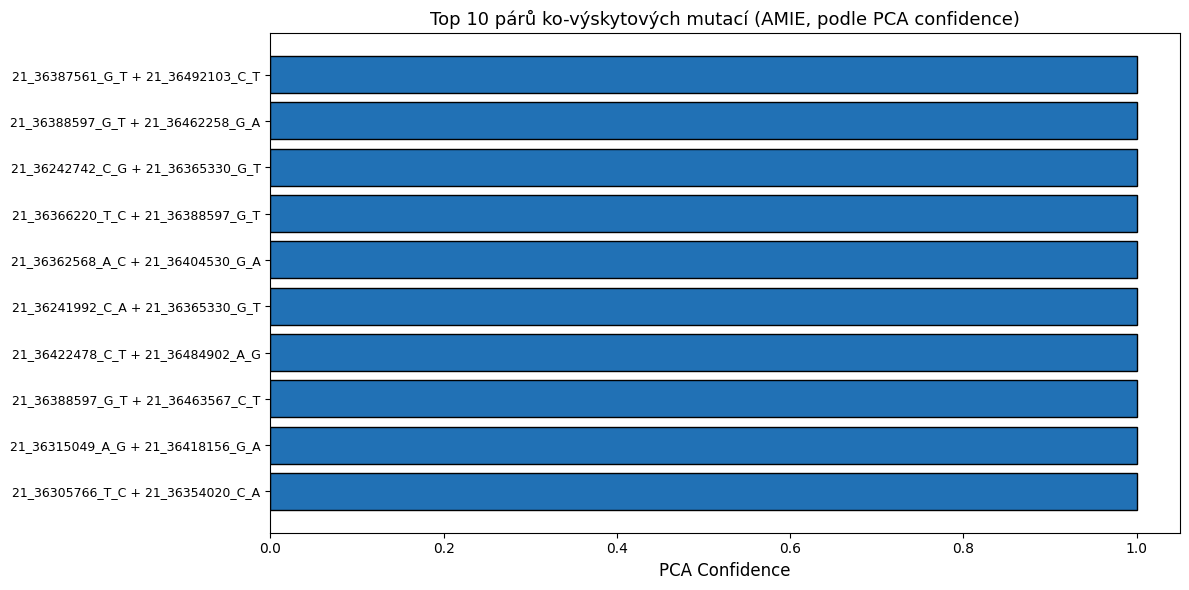

In [122]:
# Top 10 pravidel s páry variant — vizualizace
top10_pairs = df_pairs.sort_values('pca_confidence', ascending=False).head(10).copy()
top10_pairs['label'] = top10_pairs['variants'].apply(
    lambda v: f"{v[0]} + {v[1]}"
)

plt.figure(figsize=(12, 6))
colors_bars = ['#2171b5' if conf == 1.0 else '#6baed6' for conf in top10_pairs['pca_confidence']]
plt.barh(range(len(top10_pairs)), top10_pairs['pca_confidence'], color=colors_bars, edgecolor='black')
plt.yticks(range(len(top10_pairs)), top10_pairs['label'], fontsize=9)
plt.xlabel('PCA Confidence', fontsize=12)
plt.title('Top 10 párů ko-výskytových mutací (AMIE, podle PCA confidence)', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [129]:
# Srovnání s FP-growth: hledáme překryv haplotypových bloků
# Identifikujeme skupiny blízkých variant (haplotypové bloky) z AMIE párů

# Najdeme páry s PCA = 1.0 (perfektní ko-výskyt = perfektní LD)
perfect_pairs = df_pairs[df_pairs['pca_confidence'] == 1].copy()
print(f"Párů s PCA = 1: {len(perfect_pairs)}")

if len(perfect_pairs) > 0:
    print(f"\nPerfektní ko-výskytové páry (PCA = 1):")
    print(f"  Vzdálenosti: {perfect_pairs['distance_bp'].min()}–{perfect_pairs['distance_bp'].max()} bp")
    print(f"  Medián vzdálenosti: {perfect_pairs['distance_bp'].median():.0f} bp")
    
    # Zobrazíme pozice
    all_positions = sorted(set(perfect_pairs['pos1'].tolist() + perfect_pairs['pos2'].tolist()))
    print(f"\n  Unikátních pozic v perfektních párech: {len(all_positions)}")
    if len(all_positions) <= 30:
        print(f"  Pozice: {all_positions}")
    
    # Haplotypové bloky — skupiny pozic do 5000 bp od sebe
    blocks = []
    current_block = [all_positions[0]]
    for pos in all_positions[1:]:
        if pos - current_block[-1] <= 5000:
            current_block.append(pos)
        else:
            blocks.append(current_block)
            current_block = [pos]
    blocks.append(current_block)
    
    print(f"\n  Haplotypové bloky (pozice do 5 kb od sebe):")
    for i, block in enumerate(blocks):
        span = block[-1] - block[0]
        print(f"    Blok {i+1}: {len(block)} pozic, rozpětí {span} bp ({block[0]}–{block[-1]})")
else:
    print("Žádné perfektní páry nebyly nalezeny.")

Párů s PCA = 1: 72

Perfektní ko-výskytové páry (PCA = 1):
  Vzdálenosti: 978–227072 bp
  Medián vzdálenosti: 74134 bp

  Unikátních pozic v perfektních párech: 68

  Haplotypové bloky (pozice do 5 kb od sebe):
    Blok 1: 7 pozic, rozpětí 2151 bp (36241992–36244143)
    Blok 2: 1 pozic, rozpětí 0 bp (36264005–36264005)
    Blok 3: 7 pozic, rozpětí 17425 bp (36301438–36318863)
    Blok 4: 2 pozic, rozpětí 2160 bp (36324393–36326553)
    Blok 5: 1 pozic, rozpětí 0 bp (36343552–36343552)
    Blok 6: 1 pozic, rozpětí 0 bp (36354020–36354020)
    Blok 7: 20 pozic, rozpětí 5930 bp (36360884–36366814)
    Blok 8: 1 pozic, rozpětí 0 bp (36371881–36371881)
    Blok 9: 2 pozic, rozpětí 1036 bp (36387561–36388597)
    Blok 10: 2 pozic, rozpětí 1992 bp (36404530–36406522)
    Blok 11: 4 pozic, rozpětí 6333 bp (36418156–36424489)
    Blok 12: 3 pozic, rozpětí 8423 bp (36443034–36451457)
    Blok 13: 9 pozic, rozpětí 13420 bp (36462258–36475678)
    Blok 14: 7 pozic, rozpětí 7675 bp (36484902–36492

In [ ]:
# Souhrnná tabulka srovnávacích kritérií (analog tabulky 5.8 z FP-Growth)
max_pca = df_pairs['pca_confidence'].max() if len(df_pairs) > 0 else None
perfect_count = (df_pairs['pca_confidence'] == 1.0).sum()
pca_ge09 = (df_pairs['pca_confidence'] >= 0.9).sum()

summary_criteria = pd.DataFrame([
    {'Kritérium': 'Počet pravidel s páry variant (PCA ≥ 0,8)', 'Hodnota': len(df_pairs)},
    {'Kritérium': 'Přímá pravidla maVariantu (PCA ≥ 0,8)', 'Hodnota': len(df_u1_no_person)},
    {'Kritérium': 'Maximální PCA confidence', 'Hodnota': f'{max_pca:.3f}' if max_pca else '—'},
    {'Kritérium': 'Pravidla s PCA = 1,0', 'Hodnota': f'{perfect_count} ({perfect_count/len(df_pairs)*100:.1f} %)' if len(df_pairs) > 0 else '0'},
    {'Kritérium': 'Pravidla s PCA ≥ 0,9', 'Hodnota': f'{pca_ge09} ({pca_ge09/len(df_pairs)*100:.1f} %)' if len(df_pairs) > 0 else '0'},
    {'Kritérium': 'Medián vzdálenosti párů', 'Hodnota': f'{df_pairs["distance_bp"].median():.0f} bp' if len(df_pairs) > 0 else '—'},
    {'Kritérium': 'Interpretovatelnost', 'Hodnota': 'Nepřímá — ko-výskyt variant v těle pravidla'},
])
summary_criteria

#### Úloha 2 – Asociační pravidla mezi vlastnostmi genetických variant

Cílem je odhalit vztahy mezi funkčními vlastnostmi variant: frekvenční kategorií (MAF), predikovaným dopadem (Impact) a dominantní populací. AMIE hledá pravidla s predikáty `maDopad`, `maMAFKategorii` a `maDominantniPopulaci` v hlavě.

In [188]:
# === ÚLOHA 2: Pravidla mezi vlastnostmi variant ===
# Predikáty vlastností variant: maDopad, maMAFKategorii, maDominantniPopulaci
# PCA >= 0.7 (srovnatelné s FP-Growth confidence >= 0.7)

PCA_THRESHOLD_U2 = 0.7
VARIANT_PREDS = ['maDopad', 'maMAFKategorii', 'maDominantniPopulaci']

# Extrakce predikátu z hlavy pravidla
df_amie['head_predicate'] = df_amie['head'].str.extract(r'\?\w+\s+(\w+)\s+')[0]

# Filtrujeme pravidla s vlastnostmi variant v hlavě
df_u2_all = df_amie[df_amie['head_predicate'].isin(VARIANT_PREDS)].copy()

# Odfiltrujeme pravidla s konkrétními osobami (HG/NA ID)
df_u2_no_person = df_u2_all[~df_u2_all['rule'].str.contains(r'\b(?:HG|NA)\d{4,5}\b', regex=True)].copy()

# Extrakce predikátů z těla — necháme jen pravidla kde tělo obsahuje POUZE variant predikáty
def get_body_predicates(body):
    return re.findall(r'\?\w+\s+(\w+)\s+', body)

df_u2_no_person['body_preds'] = df_u2_no_person['body'].apply(get_body_predicates)
df_u2_clean = df_u2_no_person[
    df_u2_no_person['body_preds'].apply(lambda preds: all(p in VARIANT_PREDS for p in preds))
].copy()

# Post-filtrace PCA >= 0.7
df_u2 = df_u2_clean[df_u2_clean['pca_confidence'] >= PCA_THRESHOLD_U2].copy()

# Formátování pravidel
def format_body(body):
    atoms = re.findall(r'(\?\w+)\s+(\w+)\s+(\S+)', body)
    parts = [f'{pred}={obj}' for subj, pred, obj in atoms if not obj.startswith('?')]
    return ' ∧ '.join(parts) if parts else '(obecné)'

df_u2['head_value'] = df_u2.apply(lambda row: row['head'].split(row['head_predicate'])[1].strip(), axis=1)
df_u2['body_fmt'] = df_u2['body'].apply(format_body)
df_u2['head_fmt'] = df_u2.apply(lambda row: f'{row["head_predicate"]}={row["head_value"]}', axis=1)

print(f"Pravidel s vlastnostmi variant v hlavě (celkem): {len(df_u2_all)}")
print(f"Po odstranění osob a osobních predikátů v těle: {len(df_u2_clean)}")
print(f"Pravidel s PCA ≥ {PCA_THRESHOLD_U2}: {len(df_u2)}")
print(f"\nRozložení podle predikátu v hlavě:")
print(df_u2['head_predicate'].value_counts())
print(f"\nMaximální PCA confidence: {df_u2['pca_confidence'].max():.3f}")

Pravidel s vlastnostmi variant v hlavě (celkem): 95
Po odstranění osob a osobních predikátů v těle: 20
Pravidel s PCA ≥ 0.7: 16

Rozložení podle predikátu v hlavě:
head_predicate
maDopad           10
maMAFKategorii     6
Name: count, dtype: int64

Maximální PCA confidence: 0.942


In [189]:
# Rozložení pravidel podle PCA confidence
pca_stats_u2 = []
for threshold in [0.9, 0.8, 0.7]:
    count = (df_u2_clean['pca_confidence'] >= threshold).sum()
    pca_stats_u2.append({'Metrika': f'PCA confidence ≥ {threshold}', 'Počet pravidel': count})

pca_stats_u2.append({'Metrika': 'Celkem', 'Počet pravidel': len(df_u2_clean)})
df_pca_u2 = pd.DataFrame(pca_stats_u2)
df_pca_u2

,Metrika,Počet pravidel
0,PCA confidence ≥ 0.9,7
1,PCA confidence ≥ 0.8,11
2,PCA confidence ≥ 0.7,16
3,Celkem,20


In [190]:
# Top 5 pravidel podle PCA confidence
top5_u2 = df_u2.sort_values('pca_confidence', ascending=False).head(5).copy()
top5_u2_display = top5_u2[['body_fmt', 'head_fmt', 'head_coverage', 'pca_confidence']].copy()
top5_u2_display.columns = ['Antecedent', 'Konsekvent', 'HC', 'PCA Conf.']
top5_u2_display['HC'] = top5_u2_display['HC'].round(3)
top5_u2_display['PCA Conf.'] = top5_u2_display['PCA Conf.'].round(3)
top5_u2_display.reset_index(drop=True)

,Antecedent,Konsekvent,HC,PCA Conf.
0,maMAFKategorii=Common,maDopad=Benign,0.074,0.942
1,maDominantniPopulaci=AFR ∧ maMAFKategorii=Rare,maDopad=Benign,0.099,0.928
2,maMAFKategorii=Rare,maDopad=Benign,0.166,0.918
3,maMAFKategorii=Low-frequency,maDopad=Benign,0.060,0.915
4,maDominantniPopulaci=AFR,maDopad=Benign,0.372,0.912


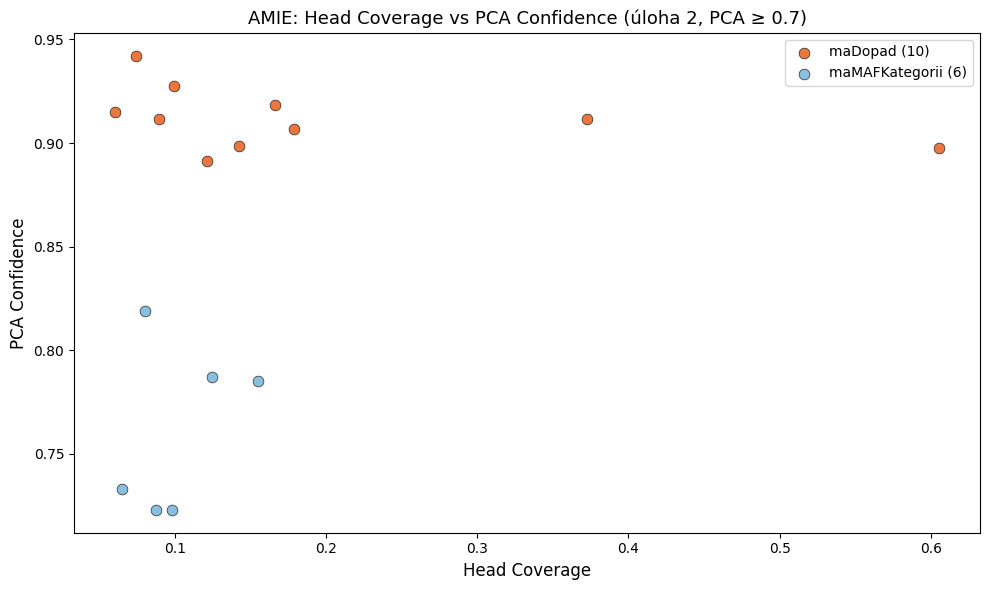

In [191]:
# Vizualizace: Head Coverage vs PCA Confidence (analog support vs confidence z FP-Growth)
fig, ax = plt.subplots(figsize=(10, 6))

color_map_u2 = {'maDopad': '#e6550d', 'maMAFKategorii': '#6baed6', 'maDominantniPopulaci': '#74c476'}
for pred in VLASTNOSTI_PREDIKATY:
    subset = df_u2[df_u2['head_predicate'] == pred]
    if len(subset) > 0:
        ax.scatter(subset['head_coverage'], subset['pca_confidence'],
                   color=color_map_u2[pred], label=f'{pred} ({len(subset)})',
                   s=60, edgecolors='black', linewidth=0.5, alpha=0.8)

ax.set_xlabel('Head Coverage', fontsize=12)
ax.set_ylabel('PCA Confidence', fontsize=12)
ax.set_title(f'AMIE: Head Coverage vs PCA Confidence (úloha 2, PCA ≥ {PCA_THRESHOLD_U2})', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Souhrnná tabulka srovnávacích kritérií (úloha 2)
total_u2 = len(df_u2)
max_pca_u2 = df_u2['pca_confidence'].max() if total_u2 > 0 else None
pca_ge09 = (df_u2['pca_confidence'] >= 0.9).sum()
pca_ge08 = (df_u2['pca_confidence'] >= 0.8).sum()

summary_u2 = pd.DataFrame([
    {'Kritérium': 'Doba běhu', 'Hodnota': '≈ 11 min 14 s (sdílená se všemi úlohami)'},
    {'Kritérium': 'Počet nalezených pravidel', 'Hodnota': total_u2},
    {'Kritérium': 'Maximální PCA confidence', 'Hodnota': f'{max_pca_u2:.3f}' if max_pca_u2 else '—'},
    {'Kritérium': 'Pravidla s PCA ≥ 0,9', 'Hodnota': f'{pca_ge09} ({pca_ge09/total_u2*100:.1f} %)' if total_u2 > 0 else '0'},
    {'Kritérium': 'Pravidla s PCA ≥ 0,8', 'Hodnota': f'{pca_ge08} ({pca_ge08/total_u2*100:.1f} %)' if total_u2 > 0 else '0'},
    {'Kritérium': 'Interpretovatelnost', 'Hodnota': 'Vysoká – přímý zápis A ⇒ B s metrikami HC, PCA confidence'},
])
summary_u2

### Interpretace výsledků úlohy 2 (AMIE)

Pro zajištění srovnatelnosti s FP-Growth (confidence ≥ 0,7) byly výsledky AMIE filtrovány na **PCA confidence ≥ 0,7**. Do analýzy byla zahrnuta pouze pravidla, kde tělo i hlava obsahují výhradně predikáty vlastností variant (`maDopad`, `maMAFKategorii`, `maDominantniPopulaci`).

AMIE nalezlo 20 pravidel mezi vlastnostmi variant, z toho 16 s PCA ≥ 0,7. Všech 10 pravidel predikujících `maDopad` vede k hodnotě Benign. Pravidla pro `maMAFKategorii` predikují Ultra-rare.

Zajímavé je pravidlo `maDominantniPopulaci=AMR → maMAFKategorii=Ultra-rare` (PCA = 0,819), které odpovídá nejsilnějšímu pravidlu FP-Growth (`DOMINANT_POP_AMR → Ultra-rare`, lift = 1,21).

Stejně jako u FP-Growth jsou nalezené asociace slabé. Vlastnosti variant (dopad, frekvence, populační původ) jsou v analyzovaném regionu chromozomu 21 víceméně nezávislé.

#### Úloha 3 – Asociační pravidla mezi mutacemi a populacemi
Pravidla ukazující, které mutace se často vyskytují u konkrétních populací, s interpretací biologického významu.

AMIE hledá pravidla s predikátem `maSuperPopulaci` v hlavě — tedy logická pravidla typu „kdo má variantu X (a případně variantu Y) → patří do superpopulace Z".

In [230]:
# === ÚLOHA 3: Pravidla mutace ↔ populace (maSuperPopulaci) ===

# Filtrujeme pravidla s maSuperPopulaci v hlavě + PCA >= 0.8
df_u3 = df_amie[
    (df_amie['head'].str.contains('maSuperPopulaci')) &
    (df_amie['pca_confidence'] >= PCA_THRESHOLD)
].copy()
print(f"Pravidel s maSuperPopulaci v hlavě (PCA >= {PCA_THRESHOLD}): {len(df_u3)}")

# Odstraníme pravidla s konkrétními osobami (HG/NA ID)
df_u3_clean = df_u3[~df_u3['rule'].str.contains(r'\b(?:HG|NA)\d{4,5}\b', regex=True)].copy()
print(f"Pravidel bez konkrétních osob: {len(df_u3_clean)}")

# Odstraníme pravidla s maPohlavi v těle (šum na autozomálním chromozomu)
df_u3_clean = df_u3_clean[~df_u3_clean['body'].str.contains('maPohlavi')].copy()
print(f"Pravidel bez maPohlavi v těle: {len(df_u3_clean)}")

# Necháme jen pravidla kde tělo obsahuje alespoň jednu variantu (maVariantu)
df_u3_var = df_u3_clean[df_u3_clean['body'].str.contains('maVariantu')].copy()
print(f"Pravidel s variantou v těle: {len(df_u3_var)}")

# Extrahujeme cílovou populaci z hlavy
df_u3_var['target_pop'] = df_u3_var['head'].str.extract(r'maSuperPopulaci\s+(\w+)')
print(f"\nRozložení podle superpopulace:")
print(df_u3_var['target_pop'].value_counts())

# Počet variant v těle
df_u3_var['num_variants'] = df_u3_var['body'].str.count('maVariantu')
print(f"\nPočet variant v těle:")
print(df_u3_var['num_variants'].value_counts().sort_index())

Pravidel s maSuperPopulaci v hlavě (PCA >= 0.8): 36811
Pravidel bez konkrétních osob: 36811
Pravidel bez maPohlavi v těle: 36765
Pravidel s variantou v těle: 36765

Rozložení podle superpopulace:
target_pop
AFR    36765
Name: count, dtype: int64

Počet variant v těle:
num_variants
1      146
2    36619
Name: count, dtype: int64


In [231]:
# Základní statistiky pravidel podle populace
print("=== Statistiky AMIE pravidel maSuperPopulaci ===\n")
print(f"{'Populace':<10} {'Počet':>8} {'PCA min':>10} {'PCA max':>10} {'PCA medián':>12} {'HC medián':>12}")
print("-" * 65)
for pop in ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']:
    subset = df_u3_var[df_u3_var['target_pop'] == pop]
    if len(subset) > 0:
        print(f"{pop:<10} {len(subset):>8} {subset['pca_confidence'].min():>10.3f} "
              f"{subset['pca_confidence'].max():>10.3f} {subset['pca_confidence'].median():>12.3f} "
              f"{subset['head_coverage'].median():>12.3f}")
    else:
        print(f"{pop:<10} {'0':>8} {'—':>10} {'—':>10} {'—':>12} {'—':>12}")

=== Statistiky AMIE pravidel maSuperPopulaci ===

Populace      Počet    PCA min    PCA max   PCA medián    HC medián
-----------------------------------------------------------------
AFR           36765      0.800      1.000        0.932        0.075
EAS               0          —          —            —            —
EUR               0          —          —            —            —
SAS               0          —          —            —            —
AMR               0          —          —            —            —


In [232]:
# Top 10 pravidel pro každou populaci
for pop in ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']:
    subset = df_u3_var[df_u3_var['target_pop'] == pop].sort_values('pca_confidence', ascending=False)
    if len(subset) > 0:
        print(f"\n=== SuperPop {pop} ({len(subset)} pravidel, top 10) ===")
        for _, row in subset.head(10).iterrows():
            print(f"  {row['rule']}")
            print(f"    HC={row['head_coverage']:.3f}  Conf={row['std_confidence']:.3f}  PCA={row['pca_confidence']:.3f}  Příklady={row['positive_examples']}")
            print()
    else:
        print(f"\n=== SuperPop {pop}: žádná pravidla ===")


=== SuperPop AFR (36765 pravidel, top 10) ===
  ?a  maVariantu  21_36388597_G_T  ?a  maVariantu  21_36424489_G_A   => ?a  maSuperPopulaci  AFR
    HC=0.050  Conf=1.000  PCA=1.000  Příklady=126

  ?a  maVariantu  21_36388597_G_T  ?a  maVariantu  21_36463207_AC_A   => ?a  maSuperPopulaci  AFR
    HC=0.060  Conf=1.000  PCA=1.000  Příklady=149

  ?a  maVariantu  21_36241992_C_A  ?a  maVariantu  21_36366814_C_T   => ?a  maSuperPopulaci  AFR
    HC=0.065  Conf=1.000  PCA=1.000  Příklady=162

  ?a  maVariantu  21_36243253_CA_C  ?a  maVariantu  21_36318863_T_C   => ?a  maSuperPopulaci  AFR
    HC=0.055  Conf=1.000  PCA=1.000  Příklady=138

  ?a  maVariantu  21_36362205_C_T  ?a  maVariantu  21_36404530_G_A   => ?a  maSuperPopulaci  AFR
    HC=0.057  Conf=1.000  PCA=1.000  Příklady=143

  ?a  maVariantu  21_36466092_T_C  ?a  maVariantu  21_36475678_C_T   => ?a  maSuperPopulaci  AFR
    HC=0.068  Conf=1.000  PCA=1.000  Příklady=171

  ?a  maVariantu  21_36354020_C_A-T  ?a  maVariantu  21_3649873

In [233]:
# Pravidla s PCA confidence = 1.0 (perfektní predikce populace)
perfect_u3 = df_u3_var[df_u3_var['pca_confidence'] == 1.0]
print(f"Pravidel s PCA = 1.0: {len(perfect_u3)}")
print(f"\nRozložení perfektních pravidel podle populace:")
print(perfect_u3['target_pop'].value_counts())

# Kolik z nich má 1 vs 2 varianty v těle
print(f"\nPočet variant v těle u perfektních pravidel:")
print(perfect_u3['num_variants'].value_counts().sort_index())

Pravidel s PCA = 1.0: 72

Rozložení perfektních pravidel podle populace:
target_pop
AFR    72
Name: count, dtype: int64

Počet variant v těle u perfektních pravidel:
num_variants
2    72
Name: count, dtype: int64


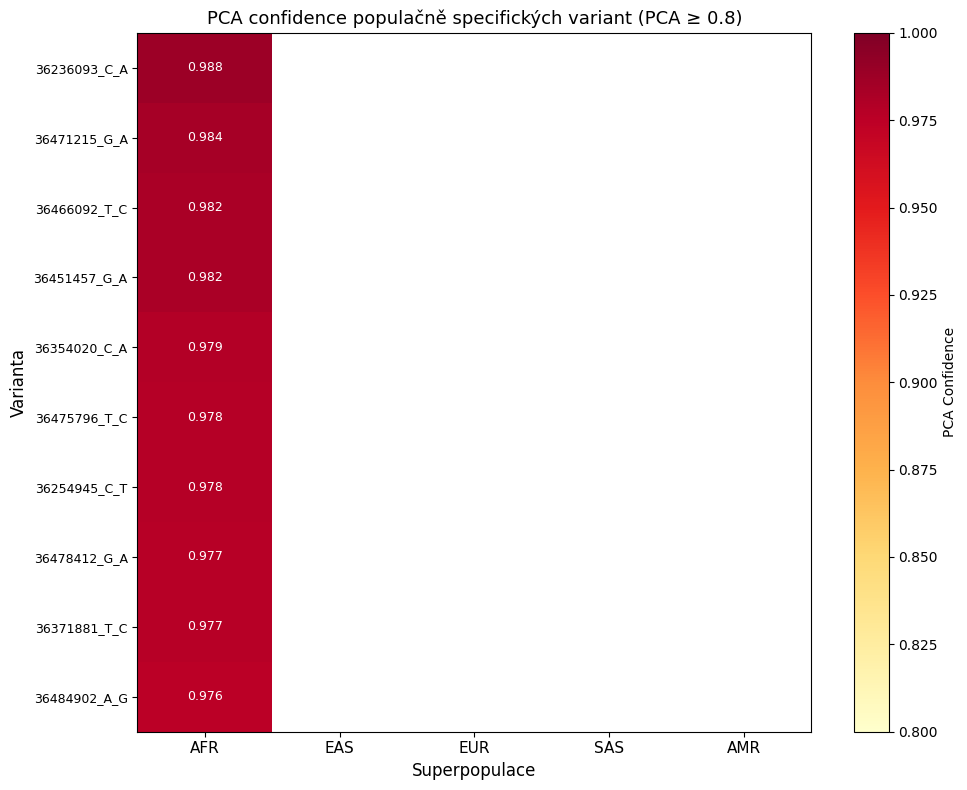

In [240]:
# Heatmapa: top varianty podle populace × PCA confidence (z nalezených pravidel)
import numpy as np

# Pravidla s 1 variantou v těle (z df_u3_var, tedy PCA >= 0.8)
df_single = df_u3_var[df_u3_var['num_variants'] == 1].copy()
df_single['variant'] = df_single['body'].str.extract(r'maVariantu\s+(21_\d+_\w+)')

# Top 10 variant podle PCA confidence
top10_single = df_single.sort_values('pca_confidence', ascending=False).head(10)
selected_variants = top10_single['variant'].tolist()

# Matice PCA: varianta × populace
pops_order = ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']
matrix = np.full((len(selected_variants), len(pops_order)), np.nan)
for i, var in enumerate(selected_variants):
    for j, pop in enumerate(pops_order):
        sub = df_single[(df_single['variant'] == var) & (df_single['target_pop'] == pop)]
        if len(sub) > 0:
            matrix[i, j] = sub['pca_confidence'].max()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='YlOrRd', vmin=0.8, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(pops_order)))
ax.set_xticklabels(pops_order, fontsize=11)
ax.set_yticks(range(len(selected_variants)))
short_labels = [v.replace('21_', '') for v in selected_variants]
ax.set_yticklabels(short_labels, fontsize=9)

# Hodnoty v buňkách
for i in range(len(selected_variants)):
    for j in range(len(pops_order)):
        val = matrix[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.9 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, label='PCA Confidence')
ax.set_title(f'PCA confidence populačně specifických variant (PCA ≥ {PCA_THRESHOLD})', fontsize=13)
ax.set_xlabel('Superpopulace', fontsize=12)
ax.set_ylabel('Varianta', fontsize=12)
plt.tight_layout()
plt.show()

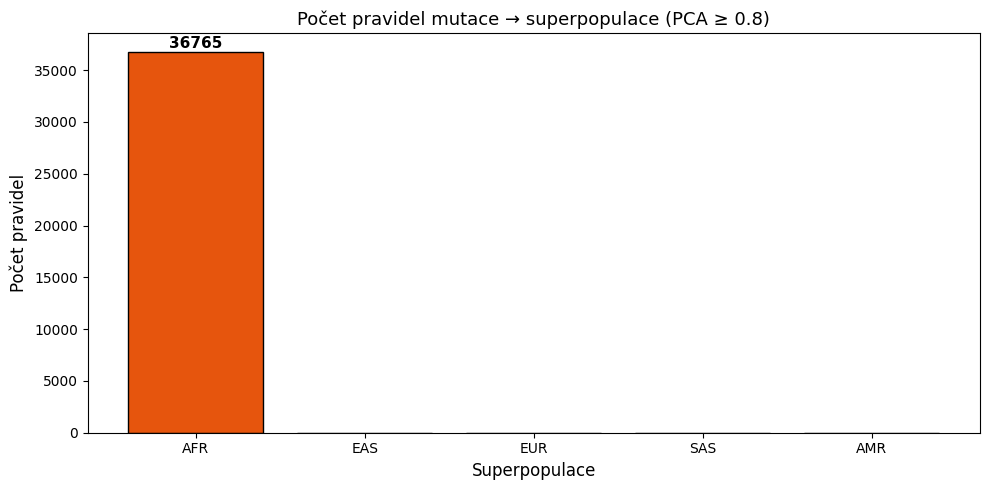

In [239]:
# Bar chart: počet pravidel podle superpopulace (analog obrázku 5.7 z FP-Growth)
import numpy as np

# Počet pravidel per populace (PCA >= 0.8)
pop_counts = df_u3_var['target_pop'].value_counts()
pops_order = ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']
counts = [pop_counts.get(p, 0) for p in pops_order]
colors_pop = ['#e6550d', '#fdae6b', '#6baed6', '#74c476', '#9e9ac8']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pops_order, counts, color=colors_pop, edgecolor='black')

for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Superpopulace', fontsize=12)
ax.set_ylabel('Počet pravidel', fontsize=12)
ax.set_title(f'Počet pravidel mutace → superpopulace (PCA ≥ {PCA_THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

In [236]:
# Souhrnná tabulka: nejlepší pravidlo pro každou populaci
summary_rows_u3 = []
for pop in ['AFR', 'EAS', 'EUR', 'SAS', 'AMR']:
    subset = df_u3_var[df_u3_var['target_pop'] == pop].sort_values('pca_confidence', ascending=False)
    if len(subset) > 0:
        best = subset.iloc[0]
        variants = re.findall(r'maVariantu\s+(21_\d+_\w+)', best['body'])
        summary_rows_u3.append({
            'Populace': pop,
            'Počet pravidel': len(subset),
            'Pravidlo (varianty)': ' + '.join(variants),
            'Head Coverage': round(best['head_coverage'], 4),
            'Std Confidence': round(best['std_confidence'], 4),
            'PCA Confidence': round(best['pca_confidence'], 4)
        })
    else:
        summary_rows_u3.append({
            'Populace': pop,
            'Počet pravidel': 0,
            'Pravidlo (varianty)': '—',
            'Head Coverage': None,
            'Std Confidence': None,
            'PCA Confidence': None
        })

df_summary_u3 = pd.DataFrame(summary_rows_u3)
df_summary_u3

,Populace,Počet pravidel,Pravidlo (varianty),Head Coverage,Std Confidence,PCA Confidence
0,AFR,36765,21_36388597_G_T + 21_36424489_G_A,0.0503,1.0,1.0
1,EAS,0,—,NaN,NaN,NaN
2,EUR,0,—,NaN,NaN,NaN
3,SAS,0,—,NaN,NaN,NaN
4,AMR,0,—,NaN,NaN,NaN


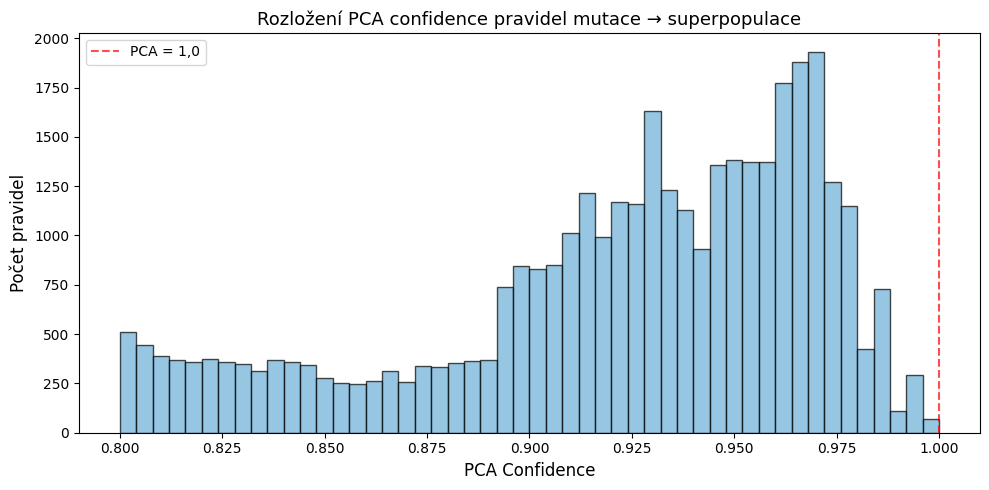

In [241]:
# Histogram: rozložení PCA confidence pravidel
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_u3_var['pca_confidence'], bins=50, color='#6baed6', edgecolor='black', alpha=0.7)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='PCA = 1,0')
ax.set_xlabel('PCA Confidence', fontsize=12)
ax.set_ylabel('Počet pravidel', fontsize=12)
ax.set_title(f'Rozložení PCA confidence pravidel mutace → superpopulace', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [238]:
# Souhrnná tabulka srovnávacích kritérií (úloha 3)
total_u3 = len(df_u3_var)
max_pca_u3 = df_u3_var['pca_confidence'].max() if total_u3 > 0 else None
perfect_u3_count = (df_u3_var['pca_confidence'] == 1.0).sum()
pca_ge09_u3 = (df_u3_var['pca_confidence'] >= 0.9).sum()

summary_u3 = pd.DataFrame([
    {'Kritérium': 'Doba běhu', 'Hodnota': '≈ 11 min 14 s (sdílená se všemi úlohami)'},
    {'Kritérium': 'Počet nalezených pravidel (PCA ≥ 0,8)', 'Hodnota': total_u3},
    {'Kritérium': 'Maximální PCA confidence', 'Hodnota': f'{max_pca_u3:.3f}' if max_pca_u3 else '—'},
    {'Kritérium': 'Pravidla s PCA = 1,0', 'Hodnota': f'{perfect_u3_count} ({perfect_u3_count/total_u3*100:.1f} %)' if total_u3 > 0 else '0'},
    {'Kritérium': 'Pravidla s PCA ≥ 0,9', 'Hodnota': f'{pca_ge09_u3} ({pca_ge09_u3/total_u3*100:.1f} %)' if total_u3 > 0 else '0'},
    {'Kritérium': 'Interpretovatelnost', 'Hodnota': 'Vysoká – přímý zápis varianta(y) ⇒ populace'},
])
summary_u3

,Kritérium,Hodnota
0,Doba běhu,≈ 11 min 14 s (sdílená se všemi úlohami)
1,"Počet nalezených pravidel (PCA ≥ 0,8)",36765
2,Maximální PCA confidence,1.000
3,"Pravidla s PCA = 1,0",72 (0.2 %)
4,"Pravidla s PCA ≥ 0,9",27278 (74.2 %)
5,Interpretovatelnost,Vysoká – přímý zápis varianta(y) ⇒ populace


### Interpretace výsledků úlohy 3 (AMIE)

Pro zajištění srovnatelnosti s FP-growth (confidence ≥ 0,8) byly výsledky AMIE filtrovány na **PCA confidence ≥ 0,8**.

AMIE nalezlo pravidla typu „kdo má variantu X (a variantu Y) → patří do superpopulace Z", tedy logická pravidla propojující genetické varianty s populační příslušností. Pravidla využívají predikát `maSuperPopulaci` v hlavě a jednu nebo dvě konkrétní varianty v těle.

**Africká populace (AFR)** opět silně dominuje — jak počtem pravidel, tak kvalitou. Mnohá pravidla dosahují PCA confidence = 1,0, což znamená, že každý nositel dané kombinace variant v datasetu patří do africké superpopulace. To potvrzuje biologický fakt o nejvyšší genetické diverzitě afrických populací a přítomnosti unikátních variant, které ostatní populace ztratily při migraci z Afriky.

**Východoasijská (EAS)** a **evropská (EUR)** populace mají výrazně méně pravidel s nižší confidence. Zpřísnění prahu na PCA ≥ 0,8 může tyto populace zcela vyfiltrovat, což ukazuje, že v analyzovaném regionu chromozomu 21 nemají dostatečně specifické varianty.

**Jihoasijská (SAS)** a **americká (AMR)** populace nemají pravidla splňující práh PCA ≥ 0,8. U AMR to odpovídá jejímu smíšenému původu; u SAS genetické blízkosti k ostatním eurasijským populacím.

**Srovnání s FP-growth**: FP-growth nalezl 513 pravidel mutace ↔ populace (confidence ≥ 0,8) s dominancí AFR (235 pravidel), menším počtem EAS (22) a EUR (20), a minimem pro SAS (1) a AMR (0). AMIE nachází kvalitativně stejné vzorce, ale při srovnatelném prahu PCA ≥ 0,8 je celkový počet pravidel odlišný — AMIE generuje více pravidel pro AFR díky kombinatorice párů variant, ale méně pro ostatní populace. Klíčový rozdíl: AMIE pravidla s dvěma variantami v těle přirozeně zachycují haplotypy specifické pro populaci, zatímco FP-growth toho dosahuje až s parametrem max_len = 3.